# Session 7: Classification task using Neural Networks

## Dataset

The MNIST dataset is a classic benchmark dataset in machine learning. It contains 70k handwritten digit images (60k for training, 10k for testing). Each image is a grayscale 28x28 picture representing a digit from 0 to 9, centered in the frame and paired with its correct label.

In this exercise, we will use MNIST to build a supervised multi-class classficiation model using NN's. The goal is to learn a mapping from the input features (pixel values) to the correct output class. The learning process involves showing the model many examples where the correct answer is known.

First, load it and visualise what is inside.

In [2]:
import torchvision
from torchvision.datasets import MNIST # Look the documentation !
import torchvision.transforms as transforms

# PIL = Python Imaging Library (see Pillow documentation)
# Transform PIL image (see Pillow documentation) to torch Tensor:
totensor = transforms.ToTensor()

# MNIST = 60k training samples, 10k test samples
mnist_train = MNIST(root='data', download=True, train=True, transform=totensor)
mnist_test = MNIST(root='data', download=True, train=False, transform=totensor)

print(mnist_train, '\n')
print(mnist_test, '\n')

print('train shape:', mnist_train.data.shape)
print('test shape:', mnist_test.data.shape)
print('classes:', mnist_train.classes)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor() 

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor() 

train shape: torch.Size([60000, 28, 28])
test shape: torch.Size([10000, 28, 28])
classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


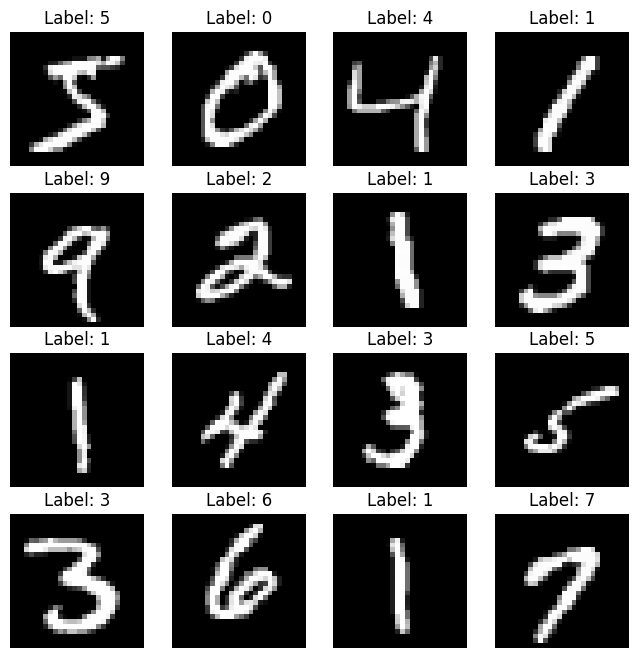

In [4]:
# Visualisation
import matplotlib.pyplot as plt

def display_n_images(dataset, n=16):
    n_col = min(n, 4)
    n_row = (n + n_col - 1) // n_col
    plt.figure(figsize=(n_col * 2, n_row * 2))
    for i in range(n):
        image, label = dataset[i]
        # Convert to 3D tensor to 2D array for plotting
        image = image.squeeze().numpy()
        # Plotting
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.show()

display_n_images(mnist_train, n=16)

## Preprocessing

Train-Test Splitting and Scaling

In [5]:
print('min pixel value:', mnist_train[0][0].min())
print('max pixel value:', mnist_train[0][0].max(), '\n')

# Scaling values to [-1, 1]
def scale(img, min_val=0, max_val=1):
    img_scaled = 2 * (img - min_val) / (max_val - min_val) - 1
    return img_scaled

# Go back to the transform function when downloading the dataset and adapt:

totensor_scaled = transforms.Compose([
    transforms.ToTensor(), # PIL Image to PyTorch Tensor
    transforms.Lambda(lambda img: scale(img)) # Scale to [-1, 1]
    # OR transforms.Normalize(mean=(0.5,), std=(0.5,)) # (X - mean)/std
])

train = MNIST(root='data', download=True, train=True, transform=totensor_scaled)
test = MNIST(root='data', download=True, train=False, transform=totensor_scaled)

print('min scaled pixel value:', train[0][0].min())
print('max scaled pixel value:', train[0][0].max(), '\n')

# Convert to PyTorch tensors for training

import torch

X_train = torch.stack([train[i][0] for i in range(len(train))]).squeeze(1) # Remove channel dimension 1
y_train = torch.tensor([train[i][1] for i in range(len(train))], dtype=torch.long)

X_test = torch.stack([test[i][0] for i in range(len(test))]).squeeze(1) # Remove channel dimension 1
y_test = torch.tensor([test[i][1] for i in range(len(test))], dtype=torch.long)

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

min pixel value: tensor(0.)
max pixel value: tensor(1.) 

min scaled pixel value: tensor(-1.)
max scaled pixel value: tensor(1.) 

X_train shape: torch.Size([60000, 28, 28])
y_train shape: torch.Size([60000])
X_test shape: torch.Size([10000, 28, 28])
y_test shape: torch.Size([10000])


# Model

As in Session 6, we will build our model using PyTorch.

Let’s start by defining its architecture:

- Each input is a 28x28 grayscale image, and the goal is to predict which digit (0-9) it represents.
  
- Since a NN expects a vector rather than a 2D image, we first flatten the 28x298 pixels into a single vector of 784 values. This vector is then passed through the layers of the network, which produce one output value per digit class.
  
- These output values represent how strongly the model believes the input image corresponds to each digit. To interpret them as probabilities, we apply a softmax function at the output layer. Softmax ensures that:
  - Each value lies between 0 and 1
  - All values sum to 1\
&rarr; This gives us a proper probability distribution over the 10 possible digits.

In [6]:
import torch
import torch.nn as nn

# Same model as before, the difference holds in the objective function

# NN Architecture
class MnistModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_hidden_layers):
        # Call the parent constructor
        super().__init__()
        # Initialise the layers
        layers = []

        # In -> Flatten
        layers.append(nn.Flatten()) # Flatten the input image

        # Flatten -> Hidden
        layers.append(nn.Linear(input_size, hidden_size)) # Pre-activation
        layers.append(nn.ReLU()) # Activation

        # Remaining layers
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size)) # Pre-activation
            layers.append(nn.ReLU()) # Activation

        # Hidden -> Out
        layers.append(nn.Linear(hidden_size, output_size)) # Pre-activation

        # Out -> Probability
        layers.append(nn.Softmax(dim=1)) # Activation

        # Combine the layers
        self.network = nn.Sequential(*layers)
    
    # Forward propagation
    def forward(self, x):
        return self.network(x)
    
# Fix the seed for reproducibility
torch.manual_seed(42)

input_size = 28 * 28

hidden_size = 100
num_hidden_layers = 2

output_size = 10

model = MnistModel(input_size, hidden_size, output_size, num_hidden_layers)

model # See how it looks like

MnistModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=100, bias=True)
    (2): ReLU()
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
    (6): Softmax(dim=1)
  )
)

## First forward pass

Before training the model, it's useful to perform an initial forward pass to verify that everything works as expected.

To do this, we first need to define the objective function and the optimisation algorithm (for example, one based on gradient descent).

For multi-class classficiation tasks, the standard choice is the cross-entropy loss.

Cross-entropy measures how far the model's predicted probability distribution is from the true distribution.

For each image, the model outputs a vector of 10 values (probabilities). In comparison, the true label can be represented as a 'one-hot' distribution (probability 1 for the correct class $\hat{k}$, 0 for all others).

Cross-entropy compares these two distributions and decreases as the model assigns a high probability to the correct class.

---

Mathematically, the concept of cross-entropy (and its meaning) comes from the Kullback–Leibler (KL) divergence, which measures the 'distance' between two probability distirbutions $q(z)$ (true) and $p(z)$ (model):

$$D_{KL}(q(z) || p(z)) = \int q(z) \log{\frac{q(z)}{p(z)}}$$

Note: The KL divergence is not commutative.

Splitting this integral in two parts, the expression can be rewritten as: $\int q \log{q} - \int q \log{p}$. The first and second term respectively correspond to the entropy $H(q)$ of the true distribution and the cross-entropy $H(q, p)$ between $q$ and $p$.

Since $H(q)$ does not depend on the model parameters $\theta$, minimising the KL divergence is equivalent to minimising the cross-entropy:

$$\hat{\theta} = \arg\min_{\boldsymbol{\theta}} \; (- H(q, p))$$

For a discrete classification problem with classes $k = 0, ..., K$, the cross-entropy for sample $i$ is:

$$CE(q_i; p_i) = - \sum_{k=0}^{K} q_i[k] \log{p_i[k]} = - \log{p_i[\hat{k}]}$$

where $q_i[k] = 1$ for $\hat{k}$ (the true label of the i-th sample) and 0 otherwise.

Note: Minimising the Cross-Entropy is equivalent to maximising the likelihood of the correct class (or minimising the negative log-likelihood criterion):

$$\hat{\theta} = \arg\max_{\boldsymbol{\theta}} \; \prod_i P(\hat{k} | x_i, \theta) = \arg\min_{\boldsymbol{\theta}} \; - \sum_i \log{P(\hat{k} | x_i, \theta)}$$

In [7]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimiser = optim.Adam(model.parameters(), lr=1e-3) # What is 'lr' ?

# One step of training (see the training loop for more details)

with torch.no_grad():
    output = model(X_train) # Forward pass
    loss = criterion(output, y_train)

Let’s visualise the model’s output for the first training sample:

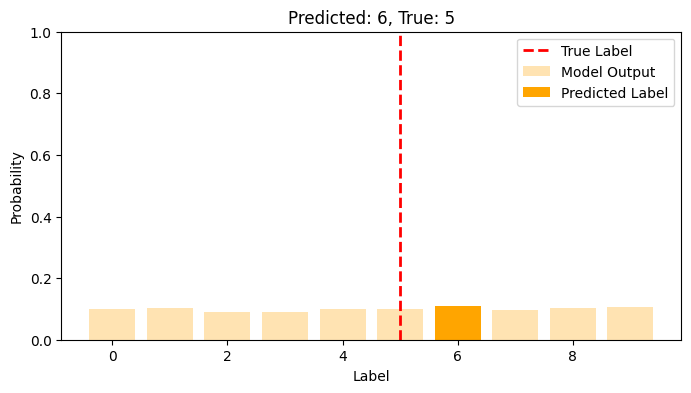

In [ ]:
ith = 0

predicted_label = torch.argmax(output, dim=1)[ith].item()
true_label = y_train[ith].item()

def display_prediction(output, predicted_label, true_label):
    plt.figure(figsize=(8, 4))
    plt.title(f'Predicted: {predicted_label}, True: {true_label}')
    plt.bar(range(10), output.numpy(), color='orange', alpha=0.3, label='Model Output')
    plt.bar(predicted_label, output[predicted_label].item(), color='orange', label='Predicted Label')
    if true_label:
        plt.axvline(x=true_label, color='red', linestyle='--', linewidth=2, label='True Label')
    plt.ylim(0, 1)
    plt.xlabel('Label')
    plt.ylabel('Probability')
    plt.legend()
    plt.show()

display_prediction(output[ith], predicted_label, true_label)

# Can you identify the true and model distributions ?

We can also assess the model’s accuracy: what is the success rate for each prediction?

Accuracy: 18.75%


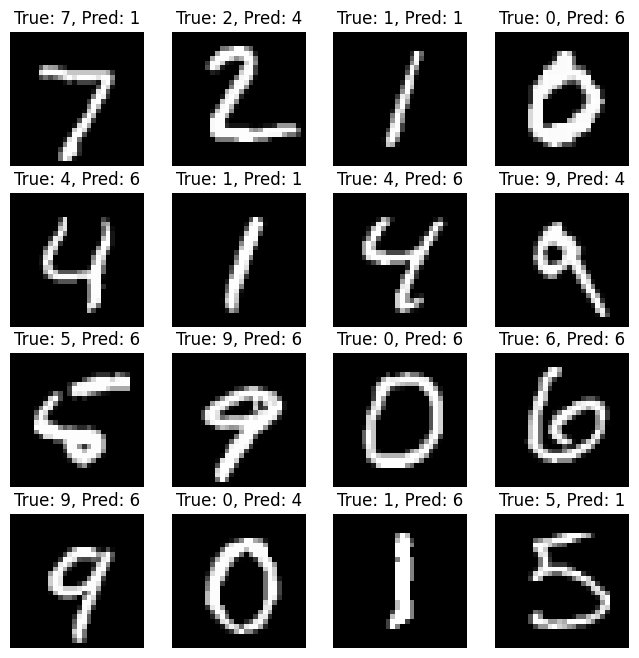

In [10]:
# Test visualisation

def display_n_predictions(model, images, labels, n=10):
    n_col = min(n, 4)
    n_row = (n + n_col - 1) // n_col
    plt.figure(figsize=(n_col * 2, n_row * 2))
    n_true = 0
    for i in range(n):
        image, label = images[i], labels[i]
        # Get the model prediction
        with torch.no_grad():
            output = model(image.unsqueeze(0)) # Add 1D
            predicted_label = torch.argmax(output, dim=1).item()
        # Calculate accuracy
        n_true += (predicted_label == label.item())
        # Plotting
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f'True: {label}, Pred: {predicted_label}')
        plt.axis('off')
    # How accurate would a random classifier be for this problem ?
    accuracy = n_true / n * 100
    print(f'Accuracy: {accuracy:.2f}%')
    plt.show()

display_n_predictions(model, X_test, y_test, n=16)

## Training

We can now repeat the training cycle (forward-backward updates) for many epochs (reminder: an epoch refers to a complete pass through the entire training dataset). 

In parallel, we can monitor the test loss (and accuracy) at each epoch.

Epoch [10/100], Train Loss: 2.1826, Train Accuracy: 36.07%, Test Loss: 2.1816, Test Accuracy: 35.95%
Epoch [20/100], Train Loss: 1.9861, Train Accuracy: 54.65%, Test Loss: 1.9855, Test Accuracy: 54.86%
Epoch [30/100], Train Loss: 1.8521, Train Accuracy: 71.06%, Test Loss: 1.8511, Test Accuracy: 71.10%
Epoch [40/100], Train Loss: 1.7463, Train Accuracy: 77.48%, Test Loss: 1.7416, Test Accuracy: 77.84%
Epoch [50/100], Train Loss: 1.6933, Train Accuracy: 80.06%, Test Loss: 1.6850, Test Accuracy: 80.79%
Epoch [60/100], Train Loss: 1.6677, Train Accuracy: 81.42%, Test Loss: 1.6602, Test Accuracy: 81.99%
Epoch [70/100], Train Loss: 1.6534, Train Accuracy: 82.31%, Test Loss: 1.6470, Test Accuracy: 82.74%
Epoch [80/100], Train Loss: 1.6442, Train Accuracy: 82.89%, Test Loss: 1.6382, Test Accuracy: 83.31%
Epoch [90/100], Train Loss: 1.6377, Train Accuracy: 83.39%, Test Loss: 1.6321, Test Accuracy: 83.85%
Epoch [100/100], Train Loss: 1.6329, Train Accuracy: 83.73%, Test Loss: 1.6276, Test Accura

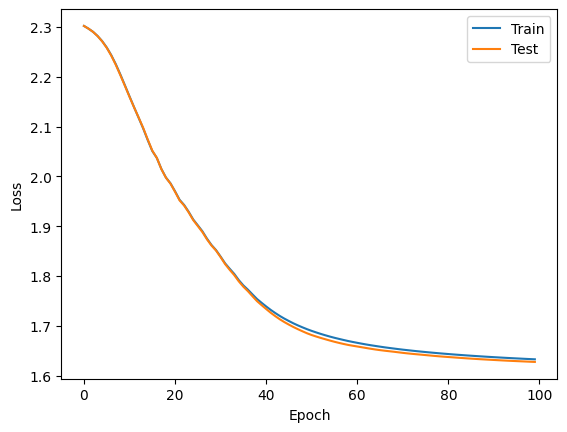

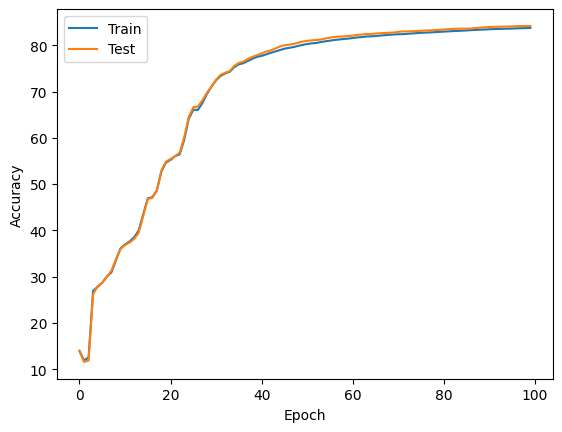

Accuracy: 87.50%


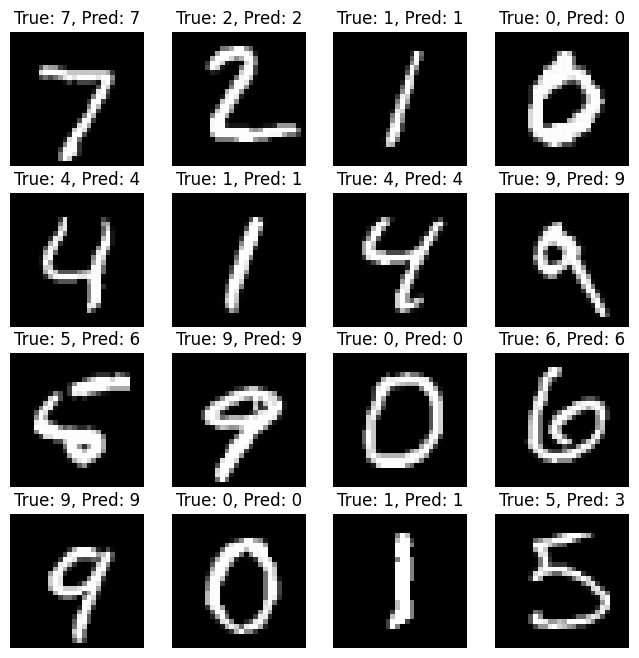

In [11]:
# Training loop

train_loss_list = []
test_loss_list = []
# Accuracy
train_acc_list = []
test_acc_list = []

num_epochs = 100 # 10 - 100

for epoch in range(num_epochs):
    # Forward pass
    output = model(X_train)

    # Training loss
    loss = criterion(output, y_train)
    # Training accuracy
    predicted_train = torch.argmax(output, dim=1)
    train_acc = (predicted_train == y_train).float().mean().item() * 100

    # Test loss (no gradient computation)
    with torch.no_grad():
        output_test = model(X_test)
        loss_test = criterion(output_test, y_test)
        # Test accuracy
        predicted_test = torch.argmax(output_test, dim=1)
        test_acc = (predicted_test == y_test).float().mean().item() * 100
    
    # Backward + Update
    optimiser.zero_grad() # Clear the gradients
    loss.backward() # Backpropagation: Compute the gradiaents
    optimiser.step() # Update the parameters

    # Saving
    train_loss_list.append(loss.item())
    test_loss_list.append(loss_test.item())
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    # Epoch statistics
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {loss.item():.4f}, Train Accuracy: {train_acc:.2f}%, '
              f'Test Loss: {loss_test.item():.4f}, Test Accuracy: {test_acc:.2f}%')

plt.plot(train_loss_list, label='Train'); plt.plot(test_loss_list, label='Test')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

plt.plot(train_acc_list, label='Train'); plt.plot(test_acc_list, label='Test')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

display_n_predictions(model, X_test, y_test, n=16)

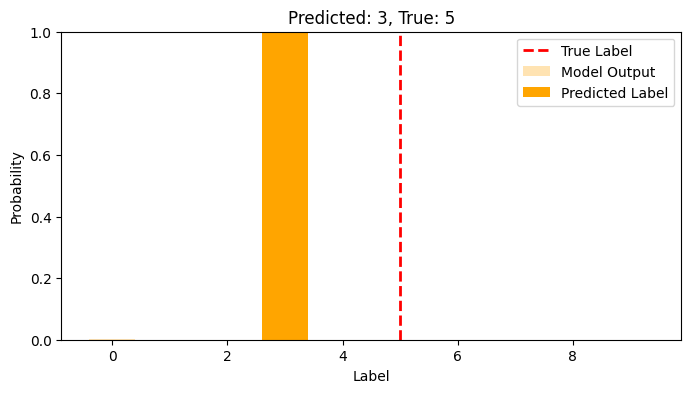

In [ ]:
# Let’s go back to the comparison in terms of probability distributions

with torch.no_grad():
    output = model(X_train) # Forward pass
    loss = criterion(output, y_train)

ith = 0

predicted_label = torch.argmax(output, dim=1)[ith].item()
true_label = y_train[ith].item()

display_prediction(output[ith], predicted_label, true_label)

## Confusion matrix

The confusion matrix is another visualisation tool to represent and assess the results of the model, and how well the classficiation performs.

Each row corresponds to the true class, and each column corresponds to the predicted class:

- Values on the diagonal represent correct predictions.
- Values off the diagonal represent mistakes.

We can see which digits the model recognises well and which ones it tends to confuse. Notably, the erros are not consistent. For example, the number 5 is often confused with a 3 or a 8, but much less frequently with a 2.



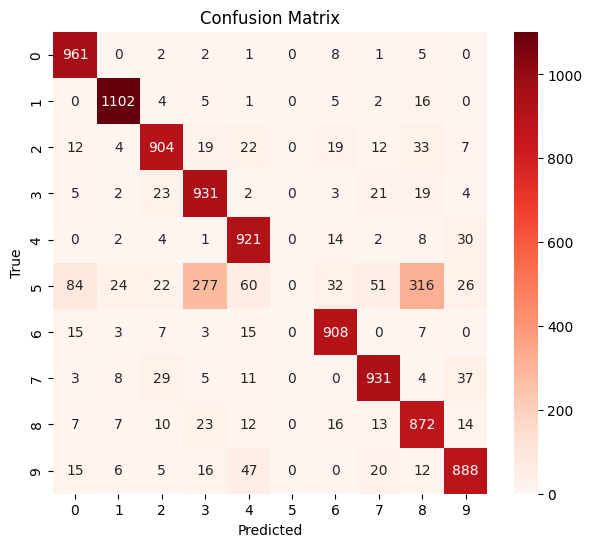

In [17]:
# Build the confusion matrix and plot it
from sklearn.metrics import confusion_matrix

with torch.no_grad():
    output_test = model(X_test)
    predicted_test = torch.argmax(output_test, dim=1)

cm = confusion_matrix(y_test, predicted_test)

# plot it
import seaborn as sns
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Bonus

What would be the output of the model for another, more general picture ?

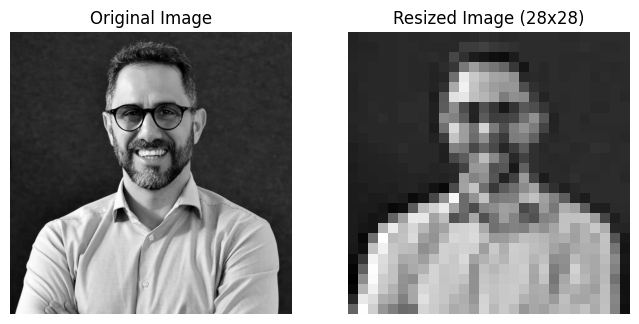

In [21]:
# Load pictures
import numpy as np
import urllib.request
from PIL import Image

url_parente = "https://raw.githubusercontent.com/burn-research/data-driven-engineering-course2026/main/Neural%20Networks/img/Parente.png"
url_parente_28 = "https://raw.githubusercontent.com/burn-research/data-driven-engineering-course2026/main/Neural%20Networks/img/Parente_28.png"

X_parente_or = np.array(Image.open(urllib.request.urlopen(url_parente)))
# Resize to 28x28
X_parente_28 = np.array(Image.open(urllib.request.urlopen(url_parente_28)))

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(X_parente_or, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(X_parente_28, cmap='gray')
axs[1].set_title('Resized Image (28x28)')
axs[1].axis('off')
plt.show()

Predicted label for Parente image: 6


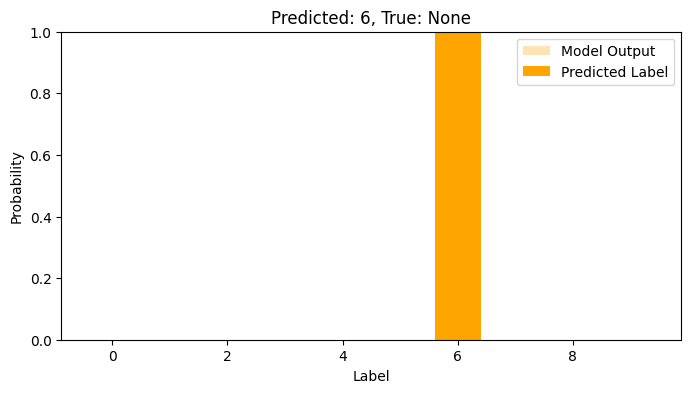

In [22]:
# Apply the model to the image

X_parente = scale(torch.tensor(X_parente_28, dtype=torch.float32))

with torch.no_grad():
    output = model(X_parente.unsqueeze(0)) # Add 1D for batch
    predicted_label = torch.argmax(output, dim=1).item()

print(f'Predicted label for Parente image: {predicted_label}')


display_prediction(output.squeeze(), predicted_label, None)

... This kind of absurd result is not surprising at all: The model was not designed or trained to recognise portraits, but to recognise numbers. We can draw at least two conclusions from this example:

- a model can only perform well within the scope of its objective function. For instance, a language model may be trained to sound correct or helpful, which is not the same as being factually accurate.

- a model inevitably reflects the data it was trained on. It will always reproduce the cultural, social or historical biases present in the training data.